#EDA
1. Import Libraries
2. Load Dataset
3. Basic Information
4. Missing Value Analysis
5. Duplicate Analysis
6. Statistical Summary
7. Univariate Analysis
8. Bivariate Analysis
9. Correlation Analysis
10. Outlier Detection
11. Insights & Conclusions


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("department_prediction_dataset.csv", keep_default_na=False)

df.head()


,patient_id,age,gender,symptoms,temperature,duration_days,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,oxygen_saturation,pain_level,symptom_severity,chronic_condition,department
0,100001,10,Female,"constipation, abdominal pain",100.1,8,125,80,62,98,5,Moderate,None,Gastroenterology
1,100002,40,Female,"mood swings, stress",98.1,3,107,63,68,100,1,Mild,None,Psychiatry
2,100003,78,Female,"ear pain, hearing loss",99.5,4,126,83,66,98,4,Moderate,Diabetes,ENT
3,100004,40,Male,"rapid heartbeat, chest pain",99.3,10,138,96,83,90,7,Moderate,Hypertension,Cardiology
4,100005,45,Other,"diarrhea, stomach pain",100.2,7,107,67,67,99,5,Moderate,None,Gastroenterology


In [17]:
df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

print("Duplicate Rows:", df.duplicated().sum())
print(
    df.drop(columns=["patient_id"]).duplicated().sum()
)


df.describe()

Duplicate Rows: 0
0


,patient_id,age,temperature,duration_days,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,oxygen_saturation,pain_level
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,46.532847,98.905148,7.182060,124.983387,79.179680,86.668233,96.865940,4.351460
std,43301.414527,23.402362,1.217403,6.482701,18.400373,15.610808,17.291807,2.838405,2.329489
min,100001.000000,1.000000,97.000000,1.000000,80.000000,50.000000,60.000000,85.000000,1.000000
25%,137500.750000,27.000000,98.100000,3.000000,111.000000,66.000000,73.000000,96.000000,2.000000
50%,175000.500000,47.000000,98.700000,5.000000,124.000000,79.000000,85.000000,97.000000,4.000000
75%,212500.250000,66.000000,99.400000,9.000000,137.000000,90.000000,97.000000,99.000000,6.000000
max,250000.000000,90.000000,103.500000,30.000000,190.000000,120.000000,140.000000,100.000000,10.000000


# Univariate Analysis
## Department Distribution


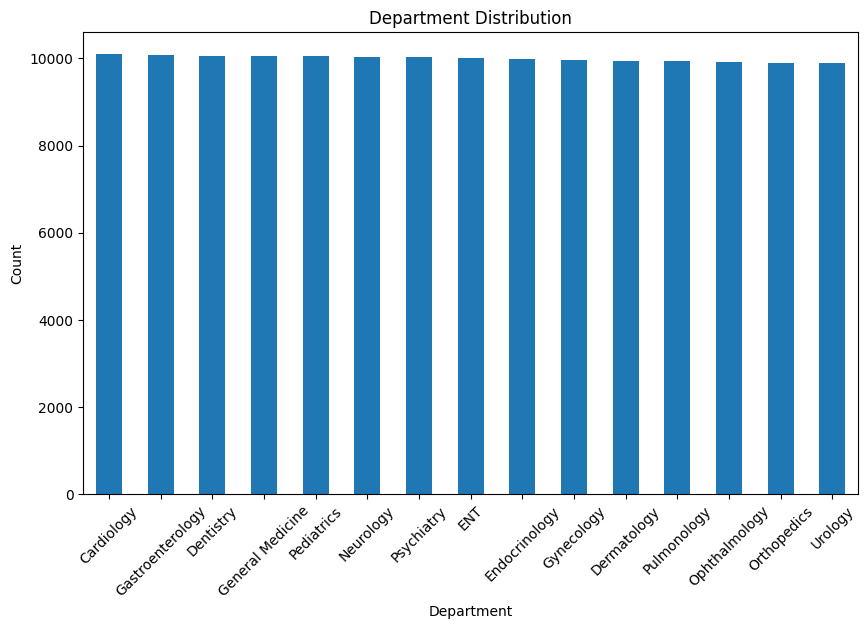

In [18]:
department_counts = df["department"].value_counts()

plt.figure(figsize=(10,6))
department_counts.plot(kind="bar")

plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Severity Distribution

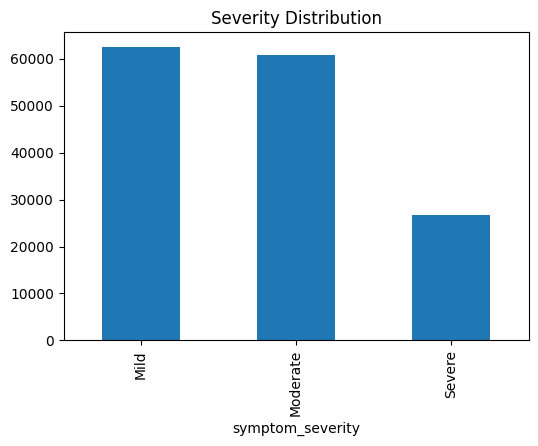

In [19]:
severity_counts = df["symptom_severity"].value_counts()

plt.figure(figsize=(6,4))
severity_counts.plot(kind="bar")

plt.title("Severity Distribution")

plt.show()

# Gender Distribution

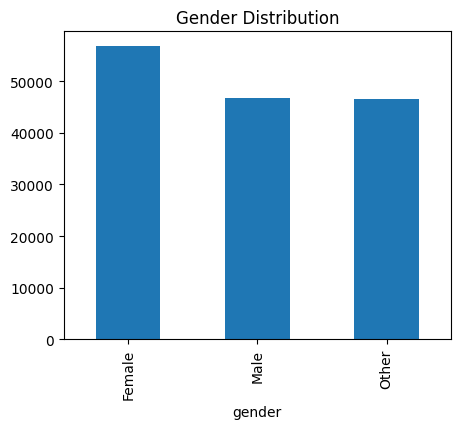

In [20]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(5,4))
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")

plt.show()

# Age Distribution

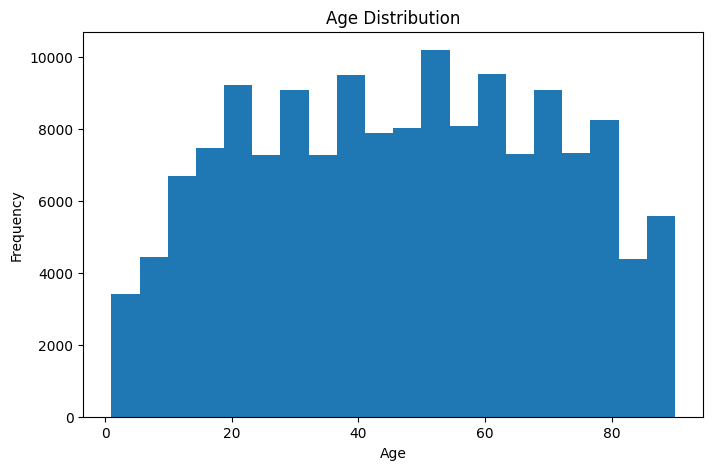

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# Temperature Distribution

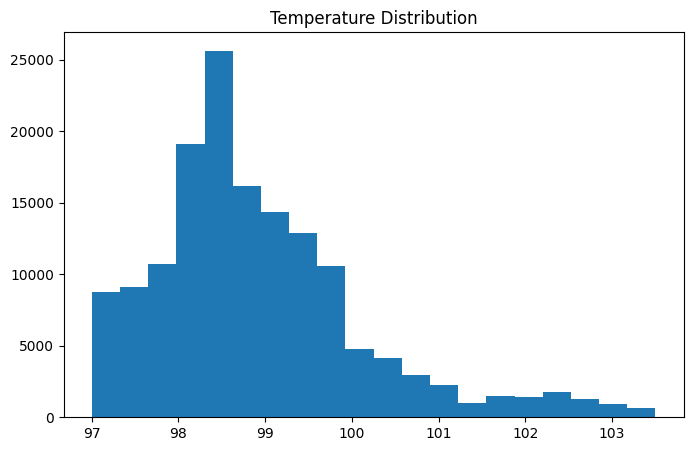

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["temperature"], bins=20)

plt.title("Temperature Distribution")

plt.show()

# Bivariate Analysis

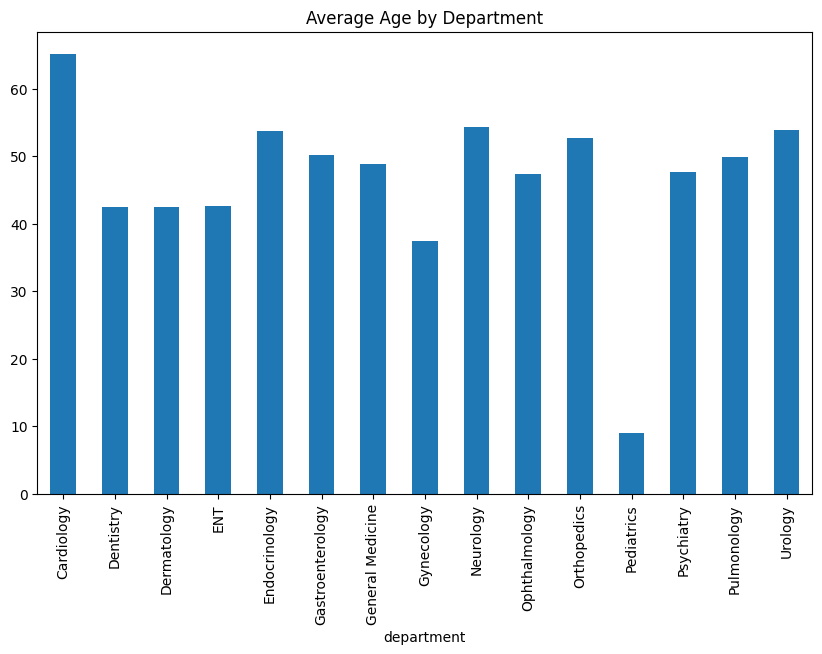

In [23]:
avg_age = df.groupby("department")["age"].mean()

plt.figure(figsize=(10,6))

avg_age.plot(kind="bar")

plt.title("Average Age by Department")

plt.show()

# Average pain level by department

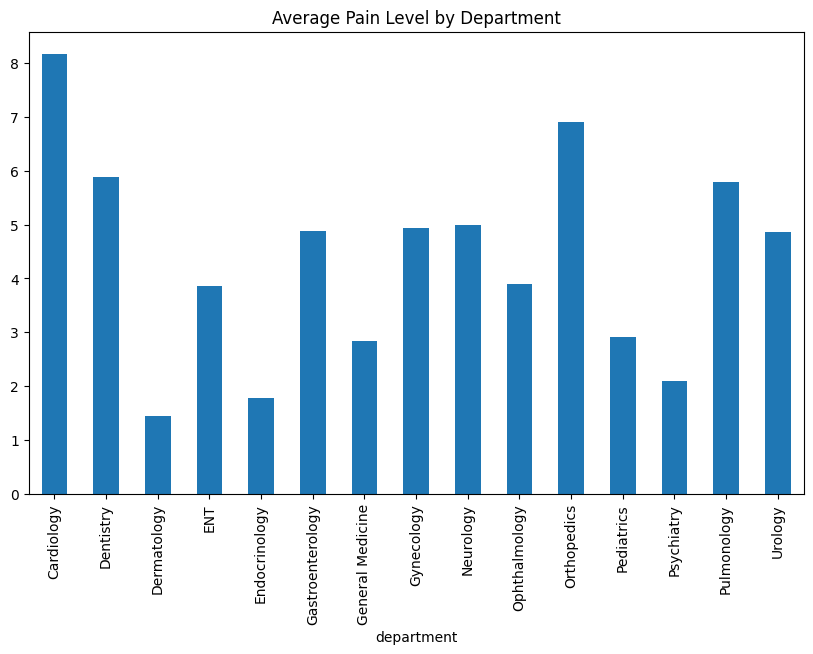

In [24]:
avg_pain = df.groupby("department")["pain_level"].mean()

plt.figure(figsize=(10,6))

avg_pain.plot(kind="bar")

plt.title("Average Pain Level by Department")

plt.show()


# Correlation Analysis



In [25]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,patient_id,age,temperature,duration_days,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,oxygen_saturation,pain_level
patient_id,1.000000,-0.000695,-0.001983,0.000826,-0.000561,-0.000788,0.000543,0.000695,0.000977
age,-0.000695,1.000000,-0.069599,0.047794,0.280389,0.279972,-0.086192,-0.121073,0.165139
temperature,-0.001983,-0.069599,1.000000,0.528504,-0.082465,-0.079262,0.188006,-0.247241,0.435352
duration_days,0.000826,0.047794,0.528504,1.000000,0.097182,0.098833,0.085215,-0.141336,0.544474
blood_pressure_systolic,-0.000561,0.280389,-0.082465,0.097182,1.000000,0.943667,0.026434,-0.215194,0.251833
blood_pressure_diastolic,-0.000788,0.279972,-0.079262,0.098833,0.943667,1.000000,0.033349,-0.219613,0.253673
heart_rate,0.000543,-0.086192,0.188006,0.085215,0.026434,0.033349,1.000000,-0.251674,0.137359
oxygen_saturation,0.000695,-0.121073,-0.247241,-0.141336,-0.215194,-0.219613,-0.251674,1.000000,-0.294793
pain_level,0.000977,0.165139,0.435352,0.544474,0.251833,0.253673,0.137359,-0.294793,1.000000


# Outlier Detection

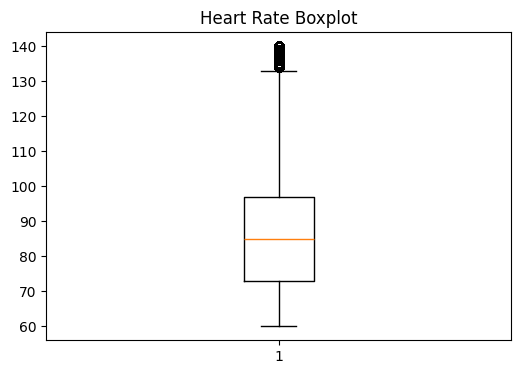

In [26]:
plt.figure(figsize=(6,4))

plt.boxplot(df["heart_rate"])

plt.title("Heart Rate Boxplot")

plt.show()

# Key Insights
No missing values.
No duplicate patient IDs.
Department distribution is balanced.
Age ranges follow department constraints.
Temperature and pain levels vary with severity.
Numerical features appear within expected ranges.